##### Dataset

In [2]:
"""Generate circles and moons datasets with 1000 and 10000 samples"""

from sklearn.datasets import make_moons, make_circles
import numpy as np

#make moon datasets
X_1k_moon, y_1k_moon = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_10k_moon, y_10k_moon = make_moons(n_samples=10000, noise=0.05, random_state=42)

#make circles datasets
X_1k_circle, y_1k_circle = make_circles(n_samples=1000, noise=0.05, random_state=42)
X_10k_circle, y_10k_circle = make_circles(n_samples=10000, noise=0.05, random_state=42)

#test the shapes of the datasets
print("Shapes of the Moon datasets:")
print(X_1k_moon.shape, y_1k_moon.shape)
print(X_10k_moon.shape, y_10k_moon.shape)
print("\n" + "-"*40 + "\n")
print("Shapes of the Circle datasets:")
print(X_1k_circle.shape, y_1k_circle.shape)
print(X_10k_circle.shape, y_10k_circle.shape)

Shapes of the Moon datasets:
(1000, 2) (1000,)
(10000, 2) (10000,)

----------------------------------------

Shapes of the Circle datasets:
(1000, 2) (1000,)
(10000, 2) (10000,)


##### Visualization

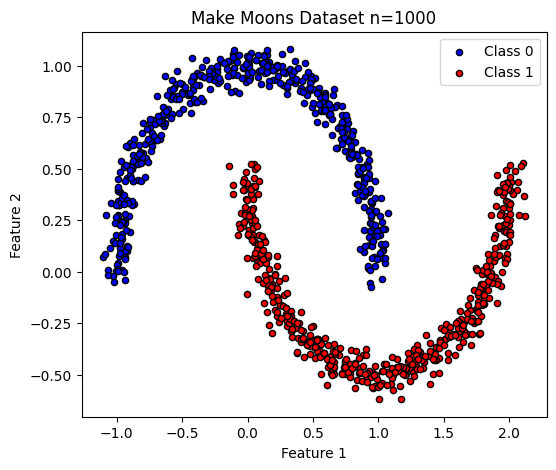

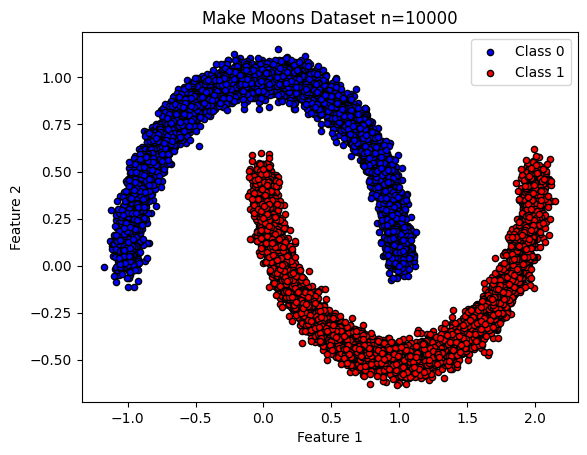

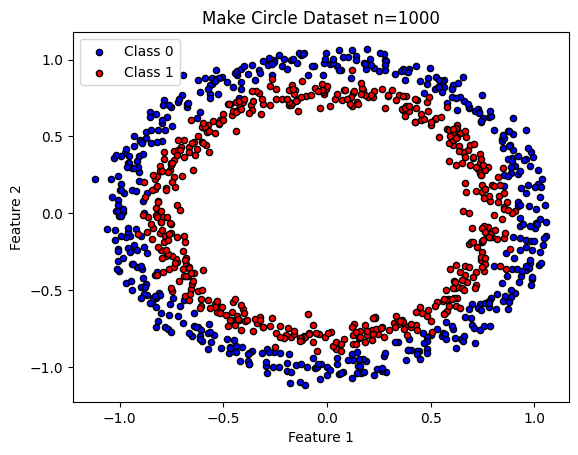

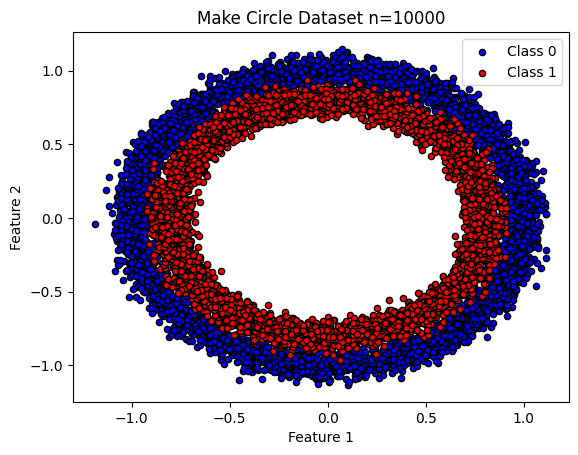

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# 1K moon dataset
plt.scatter(
    X_1k_moon[y_1k_moon == 0, 0], X_1k_moon[y_1k_moon == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_1k_moon[y_1k_moon == 1, 0], X_1k_moon[y_1k_moon == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Moons Dataset n=1000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 10k moon dataset
plt.scatter(
    X_10k_moon[y_10k_moon == 0, 0], X_10k_moon[y_10k_moon == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_10k_moon[y_10k_moon == 1, 0], X_10k_moon[y_10k_moon == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Moons Dataset n=10000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


# 1K circle dataset
plt.scatter(
    X_1k_circle[y_1k_circle == 0, 0], X_1k_circle[y_1k_circle == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_1k_circle[y_1k_circle == 1, 0], X_1k_circle[y_1k_circle == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Circle Dataset n=1000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 10k circle dataset
plt.scatter(
    X_10k_circle[y_10k_circle == 0, 0], X_10k_circle[y_10k_circle == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_10k_circle[y_10k_circle == 1, 0], X_10k_circle[y_10k_circle == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Circle Dataset n=10000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()



##### Standardize Dataset

In [4]:
def standardize(X):
    mu = X.mean(axis=0)
    std = X.std(axis=0)
    return mu, std

def standardize_transform(X, mu, std):
    return (X - mu) / std

##### K-fold Cross Validation

In [5]:
"""Implement general k-fold cross validation (use 5 folds)"""
# This function generates train and test indices for k-fold cross-validation.
# random_state is used to ensure reproducibility when shuffling the indices.

def kfold_indices(n, k=5, shuffle=True, random_state=42):
    # generate random numbers with the given random state for reproducibility
    rng = np.random.default_rng(random_state)

    # split the indices into k folds
    idx = np.arange(n)
    if shuffle: rng.shuffle(idx)
    folds = np.array_split(idx, k)

    # 1 fold = test, remaining k-1 folds = train
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        yield train_idx, test_idx

##### Metrics

In [6]:
def metrics(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

##### Simple MLP
MLP (Multi-Layer Perceptron) is a type of feedforward neural network that learns non-linear relationships between inputs and outputs.
Input layer  →  Hidden layer(s)  →  Output layer

In [7]:
class SimpleMLP:
    # binary classification with one hidden layer, tanh activation for hidden layer, sigmoid activation for output layer, and L2 regularization.

    def __init__(self, n_hidden=32, lr=0.05, epochs=180, batch_size=128, l2=1e-4, seed=42):
        # n_hidden: number of neurons in the hidden layer; 
        self.n_hidden=n_hidden
        self.lr=lr
        self.epochs=epochs
        self.batch_size=batch_size
        #batch_size: control how many samples are used to compute one gradient update during training. It is beneficial for speed and memory efficiency, especially for large datasets.
        self.l2=l2
        self.rng=np.random.default_rng(seed)

    def _init(self, d):
        # initialize weights and biases based on input dimension d.
        """rng.normal() generates random numbers from a normal distribution:
           The first argument is the mean of the distribution.
           The second argument is the standard deviation, which is scaled 
           by the input dimension d or n_hidden to help with stability during training."""
        
        # Input -> Hidden Layer
        self.W1 = self.rng.normal(0, 1/np.sqrt(d), size=(d, self.n_hidden))
        self.b1 = np.zeros(self.n_hidden) # biases for hidden layer

        # Hidden Layer -> Output Layer
        self.W2 = self.rng.normal(0, 1/np.sqrt(self.n_hidden), size=(self.n_hidden, 1))
        self.b2 = np.zeros(1) # bias for output layer

    """ Activation function: tanh for hidden layer, sigmoid for output layer.
        Loss: binary cross-entropy + L2 regularization. """
    def fit(self, X, y):
        # ensure numpy arrays and correct shape for y
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)
        
        n,d=X.shape
        self._init(d)
        for _ in range(self.epochs):
            # randomly shuffle the data at the beginning of each epoch for better training
            perm=self.rng.permutation(n)

            for start in range(0,n,self.batch_size):
                idx=perm[start:start+self.batch_size]
                xb=X[idx]; # batcth of input data
                yb=y[idx]  # batch of corresponding labels

                """ Forward pass: compute the activations and predicted probabilities """
                # hidden layer
                z1=xb @ self.W1 + self.b1
                a1=np.tanh(z1) # activation function for hidden layer: tanh

                # output layer
                z2=a1@self.W2 + self.b2
                p=1/(1+np.exp(-z2)) # activation function for output layer: sigmoid, p is the predicted probability of class 1
                
                """ Backpropagation: compute gradients and update weights and biases."""
                # From chatGPT, use prompt "MLP backpropagation for binary classification with sigmoid output and binary cross-entropy loss" to 
                # derive the gradients, which results in the following formulas:
                """ δ2 = 1/m1 (p - y)
                    dW2 = a1^T δ2 + λ W2   
                    db2 = sum(δ2)
                    δ1 = δ2 W2^T * (1 - a1^2) 
                    dW1 = xb^T δ1 + λ W1
                    db1 = sum(δ1)
                """

                # --- output layer grdients ---
                # derivate of loss w.r.t. z2, averaged over the batch size
                # sigmoid + binary cross-entropy loss has a nice property that the gradient simplifies to (p-y).
                dz2=(p-yb)/len(idx)
                # derivative of loss w.r.t. W2, includes L2 regularization term self.l2*self.W2
                dW2=a1.T@dz2 + self.l2*self.W2
                # derivative of loss w.r.t. b2
                db2=dz2.sum(axis=0)

                # --- backprop into hidden layer ---
                # derivative of loss w.r.t. z1
                da1=dz2@self.W2.T
                dz1=da1*(1-a1**2)
                # derivative of loss w.r.t. W1, includes L2 regularization term self.l2*self.W1
                dW1=xb.T@dz1 + self.l2*self.W1
                # derivative of loss w.r.t. b1
                db1=dz1.sum(axis=0)

                # parameter update
                self.W2 -= self.lr*dW2
                self.b2 -= self.lr*db2
                self.W1 -= self.lr*dW1
                self.b1 -= self.lr*db1
        return self

    def predict(self, X):
        z1 = X@self.W1 + self.b1
        a1=np.tanh(z1)
        z2 = (a1@self.W2 + self.b2).ravel()
        p=1/(1+np.exp(-z2))
        return (p>=0.5).astype(int) # threshold at 0.5 for binary classification

##### SVM with kernels
Support Vector Machine (SVM) tries to find a decision boundary that separates classes with the maximum margin.
Kernel SVM extends it so the boundary can be nonlinear.


**Linear Kernal** Measure similarity using a simple dot product; best for linearly separable data with fast computation.
-> K(x,z)=x⋅z

**Polynomial kernal** Captures more complex relationships by raising feature interactions to a power, allowing curved decision boudnaries.
-> K(x,z)=(γx⋅z+r)^d

**RBF kernal** Maps data into infinite dimensions and works well when class boundaries are higly non-linear and irregular.
-> K(x,z)=exp(−γ||x−z||^2) = exp(-γ * ( ||x||^2 + ||z||^2 - 2x^T z))

**Sigmoid Kernel** Behaves like a neural netweok activation function. 
-> K(x,z)=tanh(γx⋅z+r)

x and z are two feature vectors. 

In optimization:
primal = original problem -> optimize model parameters directly (weight w and bias b)
dual = mathematically transformed problem -> optimize Lagrange multipliers

**Dual Objective** max(​λ)​ ∑​λi​−1/2 ∑(i,j) ​λi​λj​yi​yj​K(xi​,xj​)
                subject to: 0≤λ(i)​≤C, ∑​λi​yi​=0
    prediction: f(x)=i∑​λi​yi​K(xi​,x)+b


In [50]:
class KernelSVM:
    def __init__(self, C=1.0, kernel='rbf', sigma=0.1, alpha=1, c=0, degree=2, max_kernel_samples=2500, random_state=42):
        # C：regularization parameter that controls the trade-off between maximizing the margin and minimizing classification errors. Smaller C creates a wider margin but allows more misclassifications; Bigger C creates a narrower margin but will classify more training data points correctly.
        
        # kernel: type of kernel function to use - 'linear', 'rbf', 'poly', and 'sigmoid'
        
        # sigma: parameter for RBF kernel, controls the width of the Gaussian function. Smaller sigma creates a narrower kernel, while larger sigma creates a wider kernel.
        
        # alpha: scaling parameter for polynomial and sigmoid kernels.
        
        # c: bias term for polynomial and sigmoid kernels.
        
        # degree: degree of the polynomial kernel function.

        # max_kernel_samples: limit n for kernel methods to avoid huge n*n kernel matrics

        self.C = C
        self.max_kernel_samples = max_kernel_samples
        self.random_state = random_state
        self.kernel_name = kernel

        if kernel == 'linear':
            self.kernel = self.linear_kernel
        elif kernel == 'rbf':
            self.kernel = self.rbf_kernel
            self.sigma = sigma
        elif kernel == 'poly':
            self.kernel = self.poly_kernel
            self.alpha = alpha
            self.c = c
            self.degree = degree
        elif kernel == 'sigmoid':
            self.kernel = self.sigmoid_kernel
            self.alpha = alpha
            self.c = c
        else:
            raise ValueError("Unsupported kernel type. Choose from 'linear', 'rbf', 'poly', or 'sigmoid'.")

        self.X = None
        self.Z = None
        self.lmbda = None # lagrangeian multipliers
        self.b = 0 # bias term
        self.ones = None
        self.w = None # only used for linear kernel, primal form

    def linear_kernel(self, X, Z):
        return X @ Z.T
    
    def rbf_kernel(self, X, Z):
        X2=np.sum(X**2,axis=1)[:,None] #[:, None] adds a new axis to make it a column vector for broadcasting -> reshape(n,) into (n,1)
        Z2=np.sum(Z**2,axis=1)[None,:] # shape (m,) -> (1,m) for broadcasting
        return np.exp(-self.sigma*(X2 + Z2 - 2 * X @ Z.T))
    
    def poly_kernel(self, X, Z): 
        return (self.alpha * X @ Z.T + self.c) ** self.degree
    
    def sigmoid_kernel(self, X, Z):
        return np.tanh(self.alpha * X @ Z.T + self.c)
    
    def fit(self, X, y, lr = 1e-3, epochs = 200):
        y = np.where(y == 1, 1, -1) # convert labels to -1 and 1 for SVM

        n = X.shape[0]

        if self.kernel_name == 'linear':
            # Primal linear SVM update avoids O(n^2) kernel matrix construction.
            # initialize weights and bias
            self.w = np.zeros(X.shape[1])
            self.b = 0.0
            reg = 1.0 / max(self.C, 1e-12) # convert C into regularization strength; max(C, 1e-12) is to avoid division by zero when C is very small
            
            # training loop
            for _ in range(epochs):
                """
                linear classifier: f(x) = w^T x + b
                predicted label = sign(f(x))
                when y = +1 -> (w^T x + b) >= 1
                when y = -1 -> (w^T x + b) <= -1
                so points must be on the correct side of the margin and at least 1 unit away from the decision boundary to be correctly classified without loss."""
                margin = y * (X @ self.w + self.b)

                """If points are within the margin (margin < 1), hinge loss penalizes it -> this creates a safty buffer around the decision boundary, which can improve generalization. The gradient is computed only for those points that violate the margin constraint (margin < 1). For points that are correctly classified and outside the margin (margin >= 1), the gradient is zero, and only the regularization term contributes to the update.

                mask >= 1: correct and outside margin -> no hinge loss
                0 < mask < 1: correct but inside margin -> hinge loss
                mask <= 0: misclassified -> hinge loss
                """

                mask = margin < 1.0 # correct but inside margin or misclassified
                if np.any(mask):
                    grad_w = reg * self.w - np.mean(y[mask, None] * X[mask], axis=0)
                    grad_b = -np.mean(y[mask])
                else: # correctly classified and on/outside margin: margin >= 1
                    grad_w = reg * self.w   
                    grad_b = 0.0

                self.w -= lr * grad_w
                self.b -= lr * grad_b
            return
        
        if self.max_kernel_samples is not None and n > self.max_kernel_samples:
            # Use a deterministic subset so kernel methods remain tractable on large folds.
            rng = np.random.default_rng(self.random_state)

            # get indices of positive and negative samples
            pos = np.where(y == 1)[0]
            neg = np.where(y == -1)[0]

            """balanced subset helps stable margin, better decision boundary, and avoids bias towards majority class."""
            n_sub = self.max_kernel_samples
            n_pos = min(len(pos), n_sub // 2)
            n_neg = min(len(neg), n_sub - n_pos)

            # target a roughly balanced subset(half positive, half negative if possible)
            if n_pos + n_neg < n_sub:
                extra = n_sub - (n_pos + n_neg)
                n_pos = min(len(pos), n_pos + extra)
                n_neg = min(len(neg), n_sub - n_pos)

            # if one class has fewer samples than n_sub // 2, we take all of them and fill the remaining slots with samples from the other class.
            sub_idx = np.concatenate([
                rng.choice(pos, size=n_pos, replace=False) if n_pos > 0 else np.array([], dtype=int),
                rng.choice(neg, size=n_neg, replace=False) if n_neg > 0 else np.array([], dtype=int),
            ])
            
            rng.shuffle(sub_idx)
            X = X[sub_idx]
            y = y[sub_idx]
            n = X.shape[0]

        self.X = X
        self.y = y

        self.lmbda = np.zeros(n) # initialize lagrangeian multipliers to 0
        self.b = 0 # initialize bias term to 0
        self.ones = np.ones(n) # vector of ones for bias term

        """
        Dual objective: max(labda)∑_i λ_i - 0.5 ∑_i ∑_j λ_i λ_j y_i y_j K(x_i, x_j)
        subject to: 0 <= λ_i <= C and ∑_i λ_i y_i = 0
        """

        y_outer = np.outer(y, y) # y_iy_j
        K = self.kernel(X, X) # kernel matrix K_ij = K(x_i, x_j)
        y_iy_jk_ij = y_outer * K # precompute y_iy_j K_ij for gradient step

        yy = y @ y  # precompute y^T y for projection step

        for _ in range(epochs):
            # gradient of dual objective w.r.t. labda.
            gradient = self.ones - y_iy_jk_ij @ self.lmbda
            self.lmbda += lr * gradient
            
            # projection step to enforce the constraints on λ: 0 <= λ_i <= C and ∑_i λ_i y_i = 0
            # do projection twice to ensure convergence, as one projection may not be enough to satisfy both constraints simultaneously.
            for _proj in range(2):
                self.lmbda -= y * (y @ self.lmbda) / (yy)   
                self.lmbda = np.clip(self.lmbda, 0.0, self.C)

            # find support vectors (0 < λ_i < C) to compute bias term b. Support vectors are the data points that lie on the margin or are misclassified, and they have a direct influence on the position of the decision boundary. The bias term b can be computed using any support vector, and averaging over all support vectors can provide a more stable estimate.
            idx = np.where((self.lmbda > 1e-8) & (self.lmbda < self.C - 1e-8))[0]
            if len(idx) > 0:
                # b=yi​−j∑​λj​yj​K(xj​,xi​)
                b_i = y[idx] - (self.lmbda * y) @ K[:, idx]
                self.b = float(np.mean(b_i))

    def decision_function(self, X):
        """Return real-valued scores (margin). Positive => class 1."""
        if self.kernel_name == 'linear' and self.w is not None:
            return X @ self.w + self.b
        
        K = self.kernel(self.X, X)
        # f(x)=i∑​λi​yi​K(xi​,x)+b
        return (self.lmbda * self.y) @ K + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)


##### K-fold Cross Validation Results

In [22]:

def evaluate_model_cv(model_factory, X, y, k=5, seed=42):
    fold_rows = []
    times = []
    for fold, (tr, te) in enumerate(kfold_indices(len(X), k=k, shuffle=True, random_state=seed), start=1):
        Xtr, ytr = X[tr], y[tr]
        Xte, yte = X[te], y[te]

        # standardize using TRAIN datasets only
        mu, sd = standardize(Xtr)
        Xtr_Standardize = standardize_transform(Xtr, mu, sd)
        Xte_Standardize = standardize_transform(Xte, mu, sd)

        model = model_factory()

        model.fit(Xtr_Standardize, ytr)

        ytr_pred = model.predict(Xtr_Standardize)
        yte_pred = model.predict(Xte_Standardize)

        m_tr = metrics(ytr, ytr_pred)
        m_te = metrics(yte, yte_pred)

        #print(f"Fold {fold}: Train Acc={m_tr['accuracy']:.3f}, Train F1={m_tr['f1']:.3f}, Test Acc={m_te['accuracy']:.3f}, Test F1={m_te['f1']:.3f}")

        fold_rows.append({
            "fold": fold,
            "train_accuracy": m_tr["accuracy"], "train_precision": m_tr["precision"], "train_recall": m_tr["recall"], "train_f1": m_tr["f1"],
            "test_accuracy":  m_te["accuracy"], "test_precision":  m_te["precision"], "test_recall":  m_te["recall"], "test_f1":  m_te["f1"],
        })
    mean_metrics = {
        "train_accuracy": np.mean([r["train_accuracy"] for r in fold_rows]),
        "train_f1":       np.mean([r["train_f1"] for r in fold_rows]),
        "test_accuracy":  np.mean([r["test_accuracy"] for r in fold_rows]),
        "test_f1":        np.mean([r["test_f1"] for r in fold_rows]),
    }
    return mean_metrics

def print_results_table(title, results_dict):
    # results_dict: name -> mean_metrics
    headers = ["Model", "Train Acc", "Train F1", "Test Acc", "Test F1"]
    print("\n" + title)
    print("-"*len(title))
    print("{:<18s} {:>9s} {:>9s} {:>9s} {:>9s}".format(*headers))
    for name, m in results_dict.items():
        print("{:<18s} {:>9.3f} {:>9.3f} {:>9.3f} {:>9.3f}".format(
            name,
            m["train_accuracy"], m["train_f1"],
            m["test_accuracy"],  m["test_f1"]
        ))

##### Metrics + Hyperparameters justification

We evaluate models with 5-fold cross-validation (k=5, shuffled with seed 42) and report average train/test Accuracy and F1 to measure both overall correctness and balance between Precision and Recall. Accuracy alone can be misleading when decision boundaries are difficult, so F1 is included as a robustness metric for positive-class detection quality. 

For MLP, we use n_hidden=64, lr=0.05, epochs=180, batch_size=128, and l2=1e-4, which provides enough capacity for nonlinear patterns while keeping optimization stable and limiting overfitting. For SVMs, C=1.0 is used as a moderate regularization baseline for linear, polynomial, and sigmoid kernels, while RBF uses C=10 and sigma=0.5 to allow a more flexible nonlinear boundary that better matches moons/circles geometry. Polynomial and sigmoid kernels use conservative scaling (alpha=0.1 for poly, alpha=0.01, c=0.5 for sigmoid) to avoid unstable decision functions. For kernelized SVMs, max_kernel_samples=2500 is set to keep training tractable on larger folds by controlling kernel matrix cost. Overall, these settings are chosen to balance fairness across models, nonlinear expressiveness, and computational feasibility.

##### Run Experiment

In [23]:
model_factories = {
        "MLP": lambda: SimpleMLP(n_hidden=64, lr=0.05, epochs=180, batch_size=128, l2=1e-4, seed=42),
        "SVM-linear":  lambda: KernelSVM(kernel="linear", C=1.0, sigma=0.1, alpha=1, c=0, degree=2, max_kernel_samples=None),
        "SVM-poly":    lambda: KernelSVM(kernel="poly", C=1.0, sigma=0.1, alpha=0.1, c=1, degree=3, max_kernel_samples=2500, random_state=42),
        "SVM-rbf":     lambda: KernelSVM(kernel="rbf", C=10, sigma=0.5, alpha=1, c=0, max_kernel_samples=2500, random_state=42),
        "SVM-sigmoid": lambda: KernelSVM(kernel="sigmoid", C=1.0, sigma=0.1, alpha=0.01, c=0.5, max_kernel_samples=2500, random_state=42),
    }

results = {}
print("5-Fold Cross Validation Results")
for name, factory in model_factories.items():
    #print(f"\nEvaluating {name} on Moons with 1000 samples...")
    results[name] = evaluate_model_cv(factory, X_1k_moon, y_1k_moon, k=5, seed=42)
print_results_table("Moons with 1000 samples", results)

for name, factory in model_factories.items():
    #print(f"\nEvaluating {name} on Moons with 10000 samples...")
    results[name] = evaluate_model_cv(factory, X_10k_moon, y_10k_moon, k=5, seed=42)
print_results_table("Moons with 10000 samples", results)

for name, factory in model_factories.items():
    results[name] = evaluate_model_cv(factory, X_1k_circle, y_1k_circle, k=5, seed=42)
print_results_table("Circles with 1000 samples", results)

for name, factory in model_factories.items():
    results[name] = evaluate_model_cv(factory, X_10k_circle, y_10k_circle, k=5, seed=42)
print_results_table("Circles with 10000 samples", results)




5-Fold Cross Validation Results

Moons with 1000 samples
-----------------------
Model              Train Acc  Train F1  Test Acc   Test F1
MLP                    0.949     0.949     0.949     0.948
SVM-linear             0.860     0.860     0.859     0.857
SVM-poly               0.895     0.896     0.898     0.898
SVM-rbf                1.000     1.000     1.000     1.000
SVM-sigmoid            0.870     0.870     0.871     0.870

Moons with 10000 samples
------------------------
Model              Train Acc  Train F1  Test Acc   Test F1
MLP                    1.000     1.000     1.000     1.000
SVM-linear             0.863     0.863     0.862     0.862
SVM-poly               0.916     0.916     0.915     0.915
SVM-rbf                1.000     1.000     1.000     1.000
SVM-sigmoid            0.879     0.880     0.879     0.879

Circles with 1000 samples
-------------------------
Model              Train Acc  Train F1  Test Acc   Test F1
MLP                    0.690     0.745     0.647

##### Visualize model decision outputs

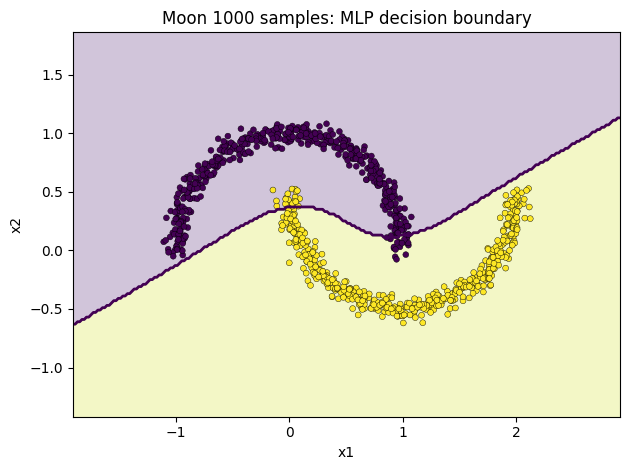

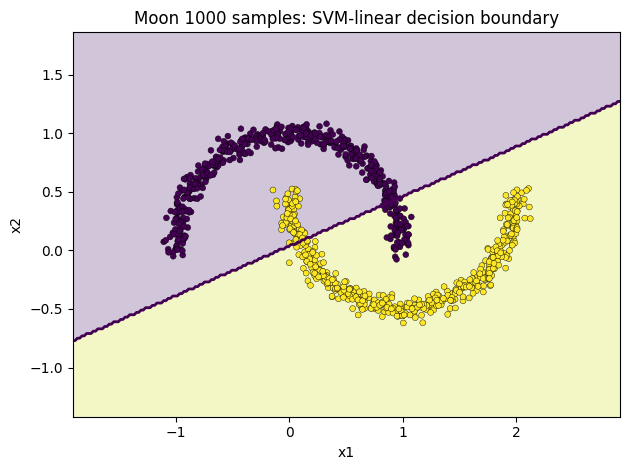

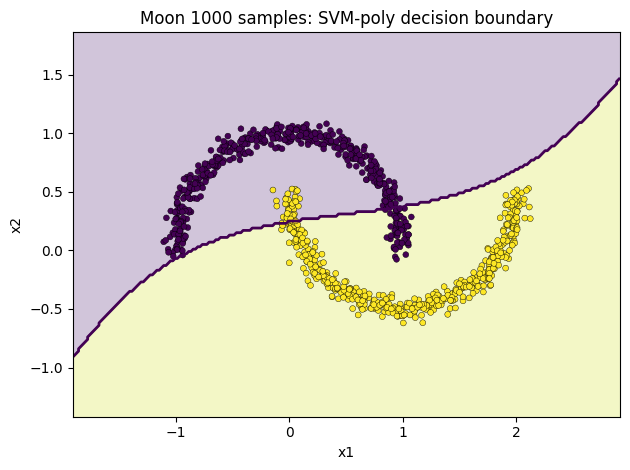

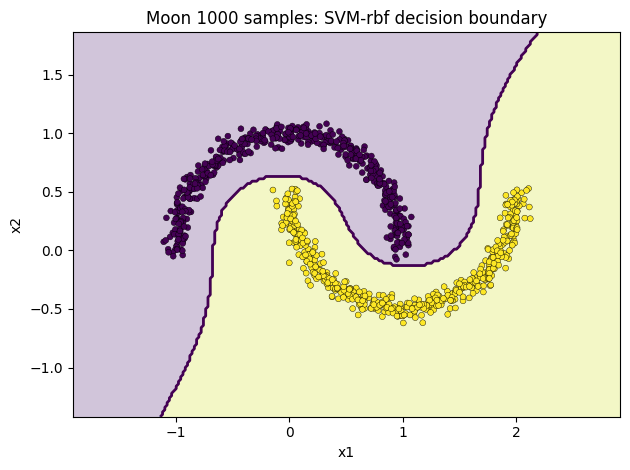

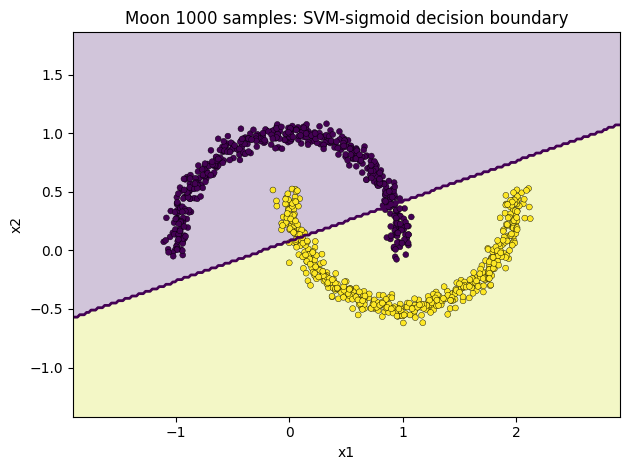

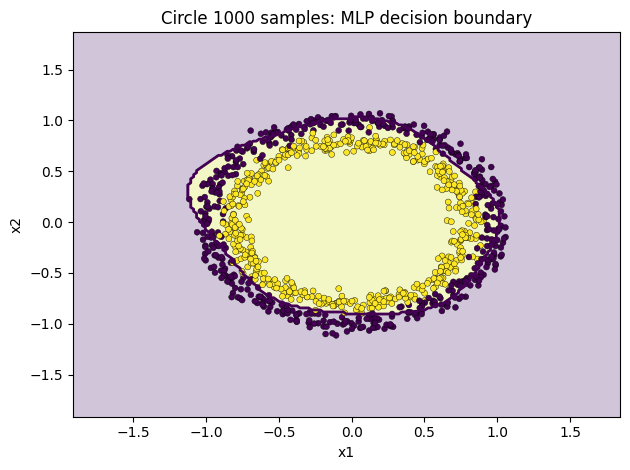

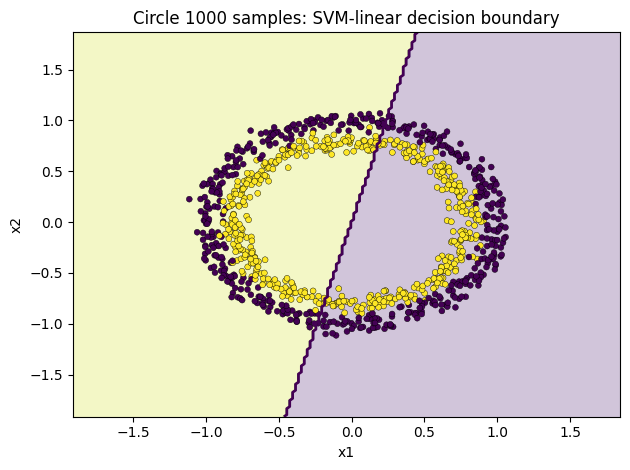

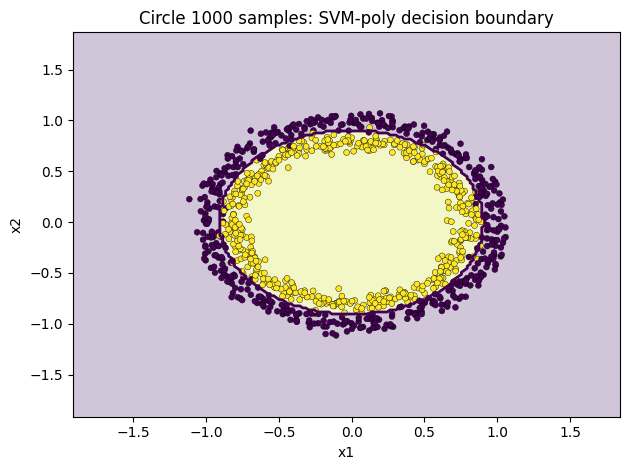

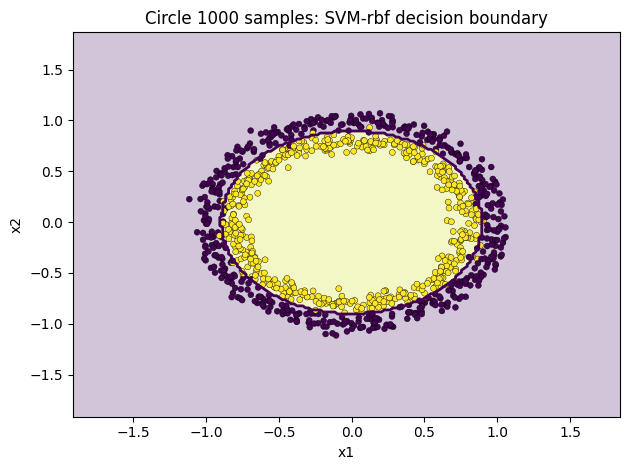

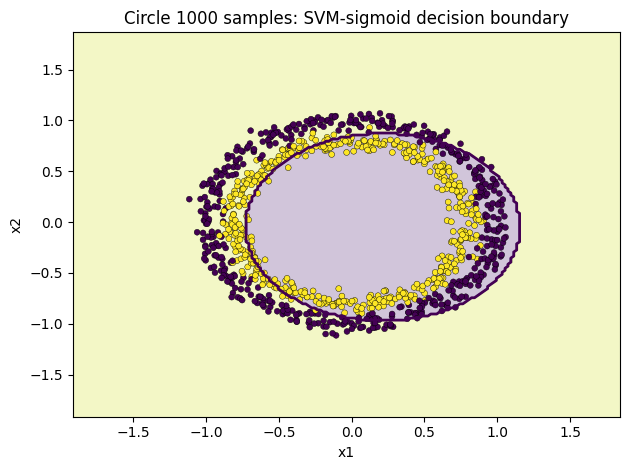

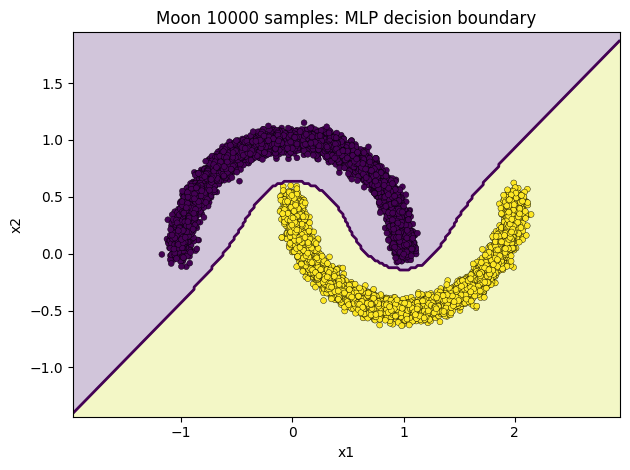

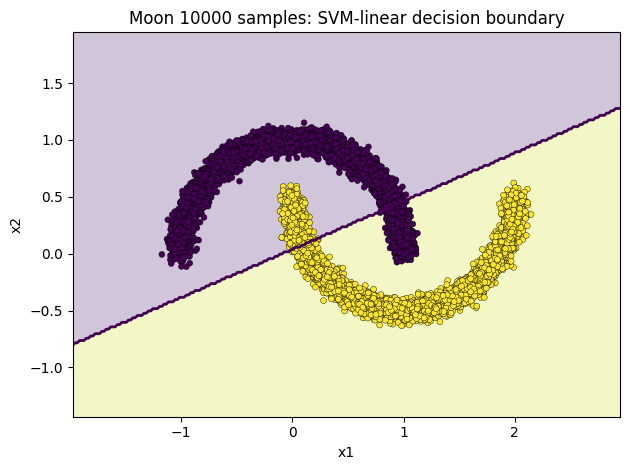

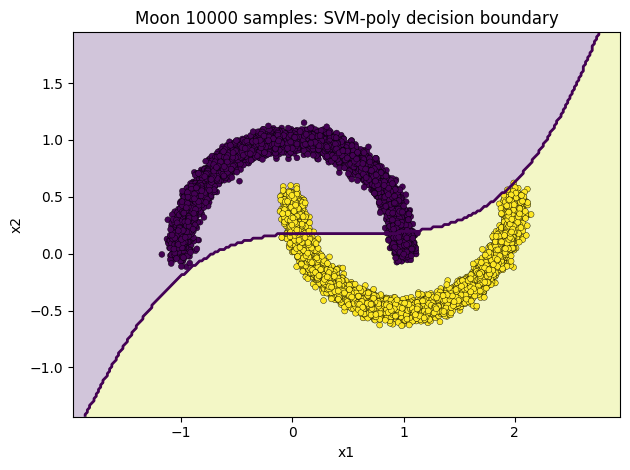

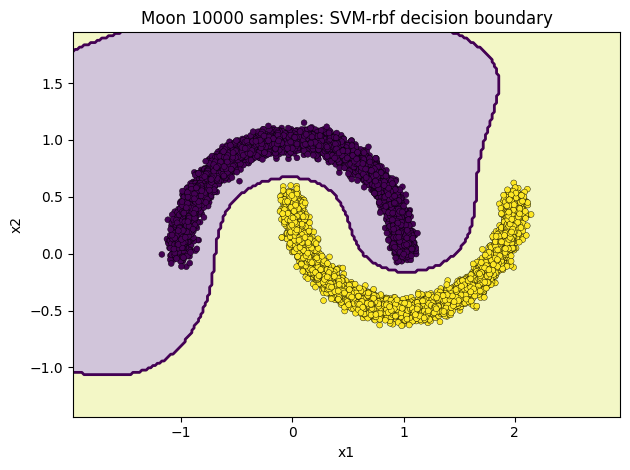

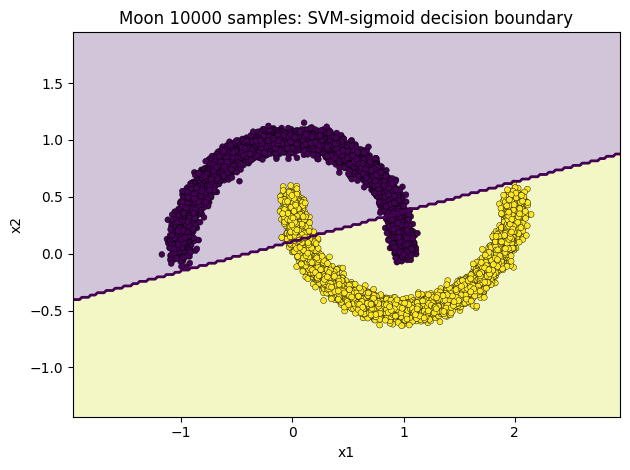

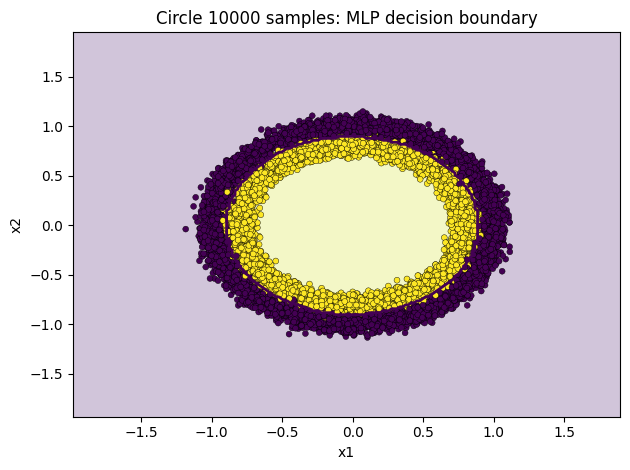

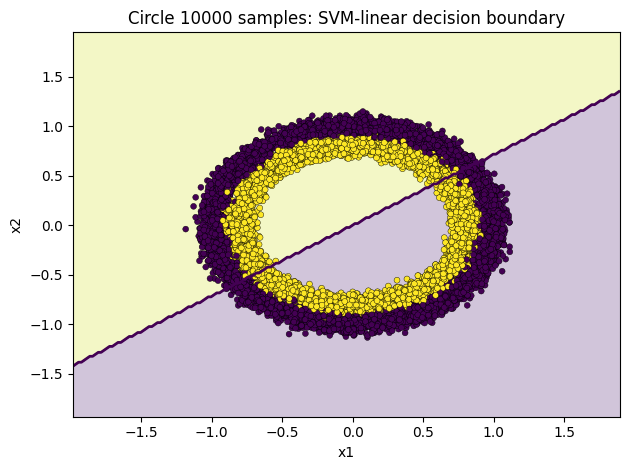

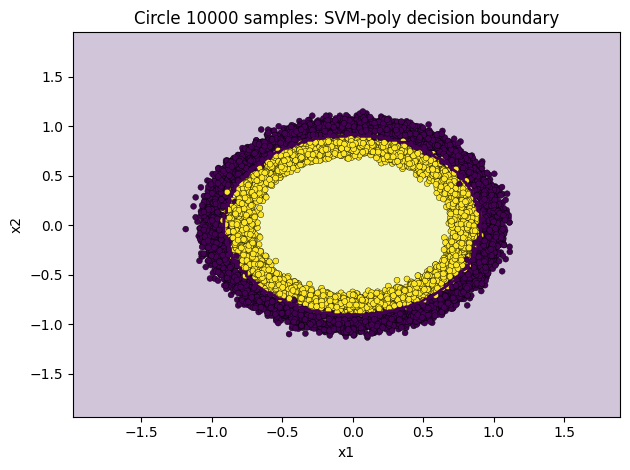

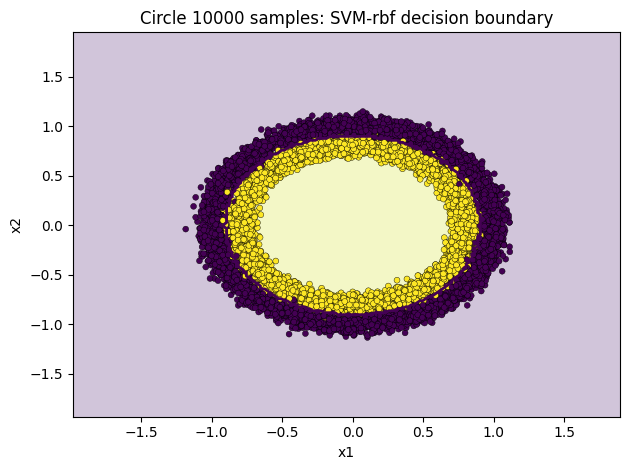

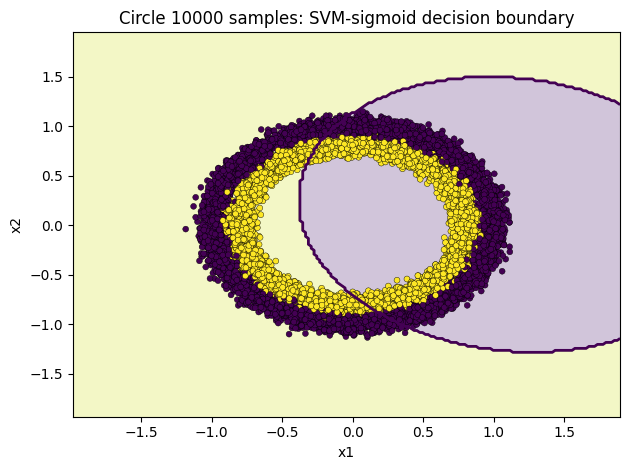

In [11]:
def plot_decision_boundary(model, X, y, mu=None, sd=None, title="", grid_step=0.02):
    X = np.asarray(X)
    y = np.asarray(y).ravel()

   # Fit on standardized or raw
    if mu is not None and sd is not None:
        X_train = (X - mu) / (sd + 1e-12)
    else:
        X_train = X

    model.fit(X_train, y)

    # From chatGPT, use prompt "code to plot decision boundary of a binary classifier in 2D"

    # Grid in original feature space (so axes are interpretable) -> define the plotting area; add 0.8 margin around the min and max of the features for better visualization.
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    # meshgrid creates a corrdinate grid. 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step),
                         np.arange(y_min, y_max, grid_step))
    # convert grid to model input format
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Standardize grid in the same way as training
    if mu is not None and sd is not None:
        grid_in = (grid - mu) / (sd + 1e-12)
    else:
        grid_in = grid

    # Predict on grid
    Z = model.predict(grid_in).reshape(xx.shape)

    # If model returns {-1,+1}, convert to {0,1} for plotting filled contours nicely
    if set(np.unique(Z)).issubset({-1, 1}):
        Z_plot = (Z > 0).astype(int)
        y_plot = (y > 0).astype(int) if set(np.unique(y)).issubset({-1, 1}) else y
    else:
        Z_plot = Z.astype(int)
        y_plot = y.astype(int)

    plt.figure()
    plt.contourf(xx, yy, Z_plot, alpha=0.25)
    plt.contour(xx, yy, Z_plot, levels=[0.5], linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y_plot, s=18, edgecolors="k", linewidths=0.3)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

def compute_mu_sd(X):
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return mu, sd

def plot_all_models_decision_boundaries(model_factories, X, y, standardize=True, title_prefix=""):
    mu, sd = (None, None)
    if standardize:
        mu, sd = compute_mu_sd(X)

    for name, factory in model_factories.items():
        model = factory()
        plot_decision_boundary(
            model, X, y, mu=mu, sd=sd,
            title=f"{title_prefix}{name} decision boundary",
            grid_step=0.02
        )

plot_all_models_decision_boundaries(model_factories, X_1k_moon, y_1k_moon, standardize=True, title_prefix="Moon 1000 samples: ")
plot_all_models_decision_boundaries(model_factories, X_1k_circle, y_1k_circle, standardize=True, title_prefix="Circle 1000 samples: ")

plot_all_models_decision_boundaries(model_factories, X_10k_moon, y_10k_moon, standardize=True, title_prefix="Moon 10000 samples: ")
plot_all_models_decision_boundaries(model_factories, X_10k_circle, y_10k_circle, standardize=True, title_prefix="Circle 10000 samples: ")

##### Results Analysis

1. **Best Kernel**
Best kernel is SVM-RBF.
SVM-RBF maps data into a high-dimensional feature space, and can learn complex nonlinear decision boudaries. Moons and circles are nonlinearl separable. Linear and low-degree polynomial kernels cannot capture these curved boundaries. 
2. **Effect of dataset size**
observations:
    MLP: test accuracy 0.949 -> 1.000 on Moon, and 0.647 ->0.978 (large improvement) on Cicle

    RBF: test accuracy stay at 1 on Moon, and 0.971 -> 0.977 on Circle
    Poly: test accuracy 0.898 -> 0.915 on Moon, and 0.967 -> 0.976 on Circle

    Linear: almost unchanged, remain poor performance on Circle ~0.48. More data does not help.
    Sigmoid：almost unchanged, remain poor performance on Circle. Limitation is kernel suitability, not data size. More data cannot fix a poorly suited model.


Larger dataset helps with when model needs more data to learn complex patterns, for example MLP. Kernel methods such as RBF and polynomial SVM already achieve high accuracy with smaller datasets and show only marginal improvement with additional data. In contrast, linear SVM and sigmoid SVM show little or no improvement because their performance is limited by model capacity or kernel suitability rather than data availability.

3. **Value of cross-validation**
Cross-validation is important. First, it provides reliable performance estimates because each sample is used for both training and testing, and the results reflect average generalization performance. Second, it reduces variance. Performance depends on data split, and cross-validation decreases randomness. Third, it will help to detect overfitting. If training accuracy is way bigger than test accuracy, it means overfitting. 

4. **Computational Costs**
SVM-Linear is usally the cheapest and fastest, because there is no kernel matrix and no pairwise comparisons. MLP computational costs will depend on epochs. If epochs is fixed, runtime grows approximately linearly with number of datasets. 
SVM-ploy, SVM-rbf, and SVM-sigmoid are more expensive than SVM-linear and MLP, because it takes O(n^2) memory and time to build the kernel matrix. Among these kernel SVMs, rbf is usually the most expensive one becuase it has many support vectors and costly distance computations. SVM-poly can become computationally intensive for very high-degree polynomials. SVM-sigmoid can be unstable and may required more iterations and/or tuning, which will be extra cost. 


##### Reflection

I understood muc more deeply how optimization and constraints actually shape the behavior of a model, especially for SVM. When using scikit-learn library, the model training appears as a simple function call, but implementing the primal and dual formulations from scratch helped me understand that SVM is fundamentally an optimization problem with strict constraints. For example, working with hinge loss, margin conditions, and the projection step in the dual made it clear how support vectors emerge and why only certain points influence the decision boundary. This gave me a much more intuitive understanding of margin maximization and the role of the regularization parameter C. Overall, implementing from scratch makes me udnerstand that machine learning algorithms are not just formulas. Instead, they are numerical optimization process. 

One important simplification in my implementation is that it assumes relatively small datasets and uses straightforward gradient or projected gradient updates. Production libraries handle many additional concerns that I did not address, such as numerical stability and automatic hyperparameter tuning. They also consider memory efficiency and handle edge cases such as class imbalance carefully. 

In [91]:
from skmultilearn.dataset import load_from_arff
import numpy as np
from sklearn.preprocessing import normalize

# ---- Train ----
X_train, Y_train = load_from_arff(
    "PlantGO-train.arff",
    label_count=12,        # PlantGO has 12 labels
    label_location="end",
    load_sparse=True
)

# ---- Test ----
X_test, Y_test = load_from_arff(
    "PlantGO-test.arff",
    label_count=12,
    label_location="end",
    load_sparse=True
)

# Convert sparse → dense 
X_train = X_train.toarray().astype(np.float32)
X_test = X_test.toarray().astype(np.float32)

Y_train = Y_train.toarray().astype(np.int32)
Y_test = Y_test.toarray().astype(np.int32)

def standardize(X):
    mu = X.mean(axis=0)
    std = X.std(axis=0)
    return mu, std

def standardize_transform(X, mu, std):
    return (X - mu) / (std+1e-8)

mu, std = standardize(X_train)
X_train = standardize_transform(X_train, mu, std)
X_test = standardize_transform(X_test, mu, std)

print("Train X:", X_train.shape)
print("Train Y:", Y_train.shape)
print("Test X:", X_test.shape)
print("Test Y:", Y_test.shape)

# number of positive samples for each label
pos_counts = Y_train.sum(axis=0)

# number of negative samples for each label
neg_counts = Y_train.shape[0] - pos_counts

print(f"Training dataset class distribution")
for i in range(Y_train.shape[1]):
    print(f"Label {i}: Pos={pos_counts[i]}, Neg={neg_counts[i]}")

# X = np.load("X_train.npy")
# y = np.load("y_train.npy")

# df = pd.DataFrame(X)
# df.to_csv("X_train.csv", index=False)
# df.to_csv("y_train.csv", index=False)


Train X: (656, 3091)
Train Y: (656, 12)
Test X: (322, 3091)
Test Y: (322, 12)
Training dataset class distribution
Label 0: Pos=39, Neg=617
Label 1: Pos=21, Neg=635
Label 2: Pos=195, Neg=461
Label 3: Pos=121, Neg=535
Label 4: Pos=27, Neg=629
Label 5: Pos=14, Neg=642
Label 6: Pos=14, Neg=642
Label 7: Pos=101, Neg=555
Label 8: Pos=106, Neg=550
Label 9: Pos=17, Neg=639
Label 10: Pos=21, Neg=635
Label 11: Pos=36, Neg=620


##### Pseudocode

**Training**
Input: X (n×d), Y (n×L) where Y_ij ∈ {0,1}
For each label j in 1..L:
    model_j = BinarySVM()
    model_j.fit(X, Y[:, j])
Store all models {model_j}

**Prediction**
Input: X
For each label j:
    score_j = model_j.decision_function(X)
    pred_j = 1 if score_j >= threshold_j else 0
Return predictions matrix (n×L)

In [92]:
class BinaryRelevanceSVM:
    """
    trains one binary SVM per label.
    if there are L labels -> train L models
    """
    def __init__(self, base_params: dict, fit_params: dict = None, threshold=0.0):
        # base_params: parameters for KernelSVM.
        self.base_params = dict(base_params)
        # extra training parameters besides KernelSVM
        self.fit_params = dict(fit_params) if fit_params is not None else {}
        # threshold: decision threshold for prediction； score >= threshold -> predict label=1
        self.threshold = float(threshold)  # global threshold
        
        self.models_ = []
        # n_labels : number of labels after fitting
        self.n_labels_ = None
        self.constant_labels_ = {}  # label_index -> constant prediction (0 or 1)

    # from chatGPT, use prompt "how to train one SVM per label"
    def fit(self, X, Y):
        Y = np.asarray(Y)
        # ensure the shape of Y
        if Y.ndim != 2:
            raise ValueError("Y must be a 2D array of shape (n_samples, n_labels).")

        self.n_labels_ = Y.shape[1]
        self.models_ = []
        self.constant_labels_ = {}

        # train one SVM per label
        for j in range(self.n_labels_):
            # extract binary labels: 0 = absent, 1 = present
            y01 = Y[:, j].astype(np.int32)

            # Handle degenerate labels (all 0s or all 1s)
            uniq = np.unique(y01)
            if uniq.size < 2:
                # SVM needs both classes to train. If only one class present, no model needed, and always predict the only class present. 
                self.models_.append(None)
                self.constant_labels_[j] = int(uniq[0])
                continue

            # trained model for label j; KernelSVM.fit handles {0,1} conversion internally
            model = KernelSVM(**self.base_params)
            model.fit(X, y01, **self.fit_params)
            self.models_.append(model)

        return self

    def decision_function(self, X):
        # safty check
        if self.n_labels_ is None:
            raise RuntimeError("Call fit() before decision_function().")

        scores = []
        n = X.shape[0]

        # used prompt from chatGPT "how to calculate score of binary SVM for one label"
        # j: label index : 0...L-1
        # m: binary SVM for that label
        for j, m in enumerate(self.models_):
            if m is None: # when for label j, during training y[:,j] was all 0s or all 1s. In this case, SVM cannot be trained because it needs two classes to define a separating hyperplane. So fit() store m = None. 
                const = self.constant_labels_[j]
                # if the label is always present, return a giant positive score
                # if the label is always absent, return a giant negative score
                # +/- 1e6 is used to make it "very confident" so it won't be close to the boundary.
                s = np.full(n, 1e6 if const == 1 else -1e6, dtype=np.float32)
            else: # the label has a trained model
                s = np.ravel(m.decision_function(X)).astype(np.float32)
            # collect scores for this label
            scores.append(s)

        return np.column_stack(scores)  # (n_samples, n_labels)
 
    def predict(self, X):
        scores = self.decision_function(X)
        return (scores >= self.threshold).astype(np.int32) 

##### Evaluation Metrics

1. Hamming Loss: It meansures the fration of label decisions that are wrong (averaged over all samples × labels)
It is a good indicator because it evaluates each label independently (robust when exact match is rare). Lower hamming loss is better.

2. Micro-averaged Precision / Recall / F1: It aggregates TP/FP/FN across all labels, and emphasizes performance on frequent labels and overall correctness. 
MicroF1 = 2TP/(2TP+FP+FN) -> best when classes are imbalanced. 

3. Macro-averaged F1
Compute F1 per label, then average → treats each label equally.
Best when you care about rare labels too.

4. Subset Accuracy (exact match)
Strict: counts a sample correct only if all labels match.
Useful but often low; include as a “hard” metric to show exact multi-label correctness.

In [ ]:
# used promots "What are the best metrics to evaluate multi-label SVM"
def multilabel_metrics(Y_true, Y_pred, eps=1e-12):
    Y_true = Y_true.astype(np.int32)
    Y_pred = Y_pred.astype(np.int32)

    n, L = Y_true.shape

    # Hamming loss
    hamming = np.mean(Y_true != Y_pred)

    # Subset accuracy (exact match)
    subset_acc = np.mean(np.all(Y_true == Y_pred, axis=1))

    # Global counts for micro metrics
    tp = int(np.sum((Y_true == 1) & (Y_pred == 1)))
    fp = int(np.sum((Y_true == 0) & (Y_pred == 1)))
    fn = int(np.sum((Y_true == 1) & (Y_pred == 0)))

    micro_p = tp / (tp + fp + eps)
    micro_r = tp / (tp + fn + eps)
    micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r + eps)

    # Per-label counts for macro metrics
    tp_l = np.sum((Y_true == 1) & (Y_pred == 1), axis=0).astype(np.float64)
    fp_l = np.sum((Y_true == 0) & (Y_pred == 1), axis=0).astype(np.float64)
    fn_l = np.sum((Y_true == 1) & (Y_pred == 0), axis=0).astype(np.float64)

    p_l = tp_l / (tp_l + fp_l + eps)
    r_l = tp_l / (tp_l + fn_l + eps)
    f1_l = 2 * p_l * r_l / (p_l + r_l + eps)

    macro_p = float(np.mean(p_l))
    macro_r = float(np.mean(r_l))
    macro_f1 = float(np.mean(f1_l))

    return {
        "HammingLoss": float(hamming),
        "SubsetAcc": float(subset_acc),
        "MicroP": float(micro_p),
        "MicroR": float(micro_r),
        "MicroF1": float(micro_f1),
        "MacroP": float(macro_p),
        "MacroR": float(macro_r),
        "MacroF1": float(macro_f1),
        "TP": tp, "FP": fp, "FN": fn
    }

In [ ]:
base_params = dict(
    C=1,
    kernel="rbf",
    sigma=0.5,               
    max_kernel_samples=2500, # keeps kernel training tractable
    random_state=42
)
fit_params = dict(lr=1e-3, epochs=200)

clf = BinaryRelevanceSVM(base_params=base_params, fit_params=fit_params, threshold=0)


# from sklearn.svm import SVC
# from sklearn.multiclass import OneVsRestClassifier
# clf = OneVsRestClassifier(
#     SVC(kernel='rbf', C=1.0, gamma='scale')
# )
# from sklearn.svm import LinearSVC
# clf = OneVsRestClassifier(
#   LinearSVC(C=1.0)

# Train
clf.fit(X_train, Y_train)

scores = clf.decision_function(X_test)

# Predict
Y_pred = clf.predict(X_test)

# Evaluate
results = multilabel_metrics(Y_test, Y_pred)
print("\nMulti-label evaluation (PlantGO):")
for k, v in results.items():
    if k in ("TP", "FP", "FN"):
        continue
    print(f"{k:10s}: {v:.6f}")
print(f"TP={results['TP']}  FP={results['FP']}  FN={results['FN']}")

from sklearn.metrics import confusion_matrix
def print_multilabel_confusion_matrices(Y_test, Y_pred):
    n_labels = Y_test.shape[1]

    for i in range(n_labels):
        cm = confusion_matrix(Y_test[:, i], Y_pred[:, i], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        print(f"\nLabel {i}")
        print("-----------------------")
        print(f"TN: {tn}  FP: {fp}")
        print(f"FN: {fn}  TP: {tp}")

# Run it
print(f"Multi-Label Confusion Matrices")
print_multilabel_confusion_matrices(Y_test, Y_pred)




Multi-label evaluation (PlantGO):
HammingLoss: 0.086180
SubsetAcc : 0.043478
MicroP    : 0.777778
MicroR    : 0.040816
MicroF1   : 0.077562
MacroP    : 0.072917
MacroR    : 0.012821
MacroF1   : 0.021807
TP=14  FP=4  FN=329
Multi-Label Confusion Matrices

Label 0
-----------------------
TN: 305  FP: 0
FN: 17  TP: 0

Label 1
-----------------------
TN: 311  FP: 0
FN: 11  TP: 0

Label 2
-----------------------
TN: 229  FP: 2
FN: 77  TP: 14

Label 3
-----------------------
TN: 261  FP: 0
FN: 61  TP: 0

Label 4
-----------------------
TN: 307  FP: 0
FN: 15  TP: 0

Label 5
-----------------------
TN: 314  FP: 0
FN: 8  TP: 0

Label 6
-----------------------
TN: 315  FP: 0
FN: 7  TP: 0

Label 7
-----------------------
TN: 273  FP: 0
FN: 49  TP: 0

Label 8
-----------------------
TN: 276  FP: 0
FN: 46  TP: 0

Label 9
-----------------------
TN: 318  FP: 0
FN: 4  TP: 0

Label 10
-----------------------
TN: 304  FP: 0
FN: 18  TP: 0

Label 11
-----------------------
TN: 304  FP: 2
FN: 16  TP: 0


##### SVM Multi Class Algorithm

##### Dataset - MNIST: Modified National Institute of Standards and Technology database
It contains: 70,000 grayscale images; Image size: 28 * 28 pixels; 10 classes (digits 0-9).

In [86]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

print("MNIST X:", X.shape)
print("MNIST y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

MNIST X: (70000, 784)
MNIST y: (70000,)
X_train shape: (56000, 784)
y_train shape: (56000,)
X_test shape: (14000, 784)
y_test shape: (14000,)


##### Pseudocode
Input: X (n×d), y (n,), classes = unique(y)
For each class k in classes:
    yk = 1 if y==k else 0
    model_k = BinarySVM()
    model_k.fit(X, yk)
Store all models {model_k}

Input: X
For each class k:
    score_k = model_k.decision_function(X)   # real-valued margins
Return argmax_k score_k for each sample


In [89]:
class OneVsRestSVM:
    def __init__(self, base_params: dict, fit_params: dict = None):
        # base_params: parameter for KernelSVM
        self.base_params = dict(base_params)
        # fit_params: training hyperparameters
        self.fit_params = dict(fit_params) if fit_params is not None else {}
        # store unique class labels
        self.classes_ = None
        self.models_ = {}

    def fit(self, X, y):
        y = np.asarray(y)
        # find all unique class labels
        self.classes_ = np.unique(y)
        self.models_ = {}

        for cls in self.classes_:
            y_bin = np.where(y == cls, 1, -1).astype(np.int32)
            model = KernelSVM(**self.base_params)
            model.fit(X, y_bin, **self.fit_params)
            self.models_[cls] = model
        return self

    def decision_function(self, X):
        # shape: (n_samples, n_classes)
        # collect one score array per class
        scores = []
        # loop over each class model
        for cls in self.classes_:
            scores.append(self.models_[cls].decision_function(X)) #compute margin scores
        return np.vstack(scores).T #[n_sampels, n_classes]

    def predict(self, X):
        scores = self.decision_function(X)
        # each row is a sample, and find index of larges score -> select the class with largest margin
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx] # conver index back to actual class label.

##### Metrics:
MNIST classes(digits 0-9) are approximately balance, So accuracy is meaningful. 
Macro-F1 is also evaluated because even though MNIST dataset is roughly balanced, some digits are harder. Accuracy alone can hide some weak classes. Macro-F1 evaluates performance per class and averages equally across digits to make sure that performance on difficult digits is not masked by easier ones. 


In [90]:
def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(y_true == y_pred))

def per_class_prf1(y_true, y_pred, n_classes=10, eps=1e-12):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    prec = np.zeros(n_classes, dtype=np.float64)
    rec  = np.zeros(n_classes, dtype=np.float64)
    f1   = np.zeros(n_classes, dtype=np.float64)

    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        prec[c] = tp / (tp + fp + eps)
        rec[c]  = tp / (tp + fn + eps)
        f1[c]   = 2 * prec[c] * rec[c] / (prec[c] + rec[c] + eps)

    return prec, rec, f1

def macro_f1(y_true, y_pred, n_classes=10):
    _, _, f1 = per_class_prf1(y_true, y_pred, n_classes=n_classes)
    return float(np.mean(f1))

def confusion_matrix(y_true, y_pred, n_classes=10):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

base_params = dict(C=10, kernel="rbf", sigma=0.05, max_kernel_samples=2500, random_state=42)
fit_params  = dict(lr=1e-3, epochs=300)

clf = OneVsRestSVM(base_params=base_params, fit_params=fit_params)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)          
y_pred = np.asarray(y_pred).ravel()

print("Test Accuracy:", accuracy(y_test, y_pred))
print("Test Macro-F1:", macro_f1(y_test, y_pred, n_classes=10))

prec, rec, f1 = per_class_prf1(y_test, y_pred, n_classes=10)
for c in range(10):
    print(f"class {c}: P={prec[c]:.4f} R={rec[c]:.4f} F1={f1[c]:.4f}")

cm = confusion_matrix(y_test, y_pred, n_classes=10)
print("Confusion Matrix:\n", cm)


Test Accuracy: 0.28564285714285714
Test Macro-F1: 0.27123892768132085
class 0: P=0.8519 R=0.0666 F1=0.1236
class 1: P=0.9991 R=0.7403 F1=0.8505
class 2: P=0.0845 R=0.0129 F1=0.0223
class 3: P=0.1294 R=1.0000 F1=0.2291
class 4: P=0.8802 R=0.2637 F1=0.4059
class 5: P=0.5278 R=0.0150 F1=0.0293
class 6: P=0.7945 R=0.1687 F1=0.2783
class 7: P=0.9340 R=0.2426 F1=0.3852
class 8: P=0.6667 R=0.0132 F1=0.0259
class 9: P=0.9426 R=0.2243 F1=0.3624
Confusion Matrix:
 [[  92    0   16 1271    2    0    0    0    0    0]
 [  15 1166   70  184   23   17   57   21    9   13]
 [   0    0   18 1380    0    0    0    0    0    0]
 [   0    0    0 1428    0    0    0    0    0    0]
 [   1    0    5  995  360    0    1    0    0    3]
 [   0    0    6 1237    1   19    0    0    0    0]
 [   0    0   17 1126    0    0  232    0    0    0]
 [   0    1   13 1085    3    0    0  354    0    3]
 [   0    0   18 1327    0    0    2    0   18    0]
 [   0    0   50 1005   20    0    0    4    0  312]]


##### Reflection:
What is the fundamental difference between multi-label and multi-
class classification, and why does this difference matter when designing an SVM-based solution?
How did your training and evaluation pipelines differ between the two?

**Fundamental difference**: 
Multi-class classification: each sample belongs to exactly one class.
Multi-label classification: each sample can belong to multiple classes simultaneously. 

**Why the fundamental differences matter**: 
SVM is fundamentally a binary classifier. The way to extend it to multi-lable or multi-class depends on the problem structure. This difference matters for SVM design because multi-class requires selecting a single class using an argmax over decision scores, meaning classifier outputs must be comparable. In contrast, multi-label classification treats each label as an independent binary problem and uses thresholding rather than argmax, so score comparability across classifiers is not required.

**Training and evaluation pipelines differences**:

Multi-class:
Accuracy meaningful
Macro-F1 shows per-class balance
Confusion matrix: size K*K

Multi-label: 
Hamming Loss
Micro-F1
Macro-F1
Subset Accuracy
Per-label confusion matrices






